<a href="https://colab.research.google.com/github/RohanKJoseph/IPRS_Tasks/blob/main/Task_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Feature Scaling and Comparative Analysis



##Importing the libraries required

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import matplotlib.pyplot as plt # for demonstrating the comparison
import seaborn as sns


##connecting with the DB

In [ ]:
data = pd.read_csv('/content/fitness_activity_100+_preprocess.csv') #connecting with the dataset using pd
print(pd.DataFrame(data)) #for checking the connectivity

   User_ID  Steps_Per_Day  Calories_Burned  Workout_Minutes
0       U1           9270              581               91
1       U2          17795              735              119
2       U3           2860              341               17
3       U4           7390              381              117
4       U5          15418              449               84
..     ...            ...              ...              ...
95     U96          15417              404               56
96     U97           5843              564              113
97     U98           9989              556               21
98     U99          11692              462               30
99    U100          14990              812              104

[100 rows x 4 columns]


In [ ]:
data.isnull().sum() #just checking for the missing datas

,0
User_ID,0
Steps_Per_Day,0
Calories_Burned,0
Workout_Minutes,0


##1. Scale the dataset using Standard Scaling


In [ ]:
scaler = StandardScaler()

# Drop the 'User_ID' column as it's not numerical and not suitable for scaling
data_numerical = data.drop(columns=['User_ID'])

data_standard = scaler.fit_transform(data_numerical) #scaling with standard scaling

print("Standard Scaled Dataset")
print("="*55)
print(pd.DataFrame(data_standard, columns=data_numerical.columns))

Standard Scaled Dataset
    Steps_Per_Day  Calories_Burned  Workout_Minutes
0       -0.159517         0.183726         0.678568
1        1.722954         0.920927         1.543380
2       -1.574958        -0.965159        -1.607006
3       -0.574654        -0.773678         1.481608
4        1.198071        -0.448161         0.462365
..            ...              ...              ...
95       1.197850        -0.663577        -0.402446
96      -0.916259         0.102346         1.358063
97      -0.000749         0.064050        -1.483461
98       0.375304        -0.385929        -1.205486
99       1.103561         1.289527         1.080088

[100 rows x 3 columns]


##2.  Scale the dataset again using Min-Max Scaling

In [ ]:
min_max_scaler = MinMaxScaler()

data_minmax = min_max_scaler.fit_transform(data_numerical) #scaling with  min max scaler

print("Min-Max Scaled Dataset")
print("="*55)
print(pd.DataFrame(data_minmax, columns=data_numerical.columns))

Min-Max Scaled Dataset
    Steps_Per_Day  Calories_Burned  Workout_Minutes
0        0.450130         0.555245         0.730769
1        0.992054         0.770629         1.000000
2        0.042655         0.219580         0.019231
3        0.330621         0.275524         0.980769
4        0.840951         0.370629         0.663462
..            ...              ...              ...
95       0.840887         0.307692         0.394231
96       0.232280         0.531469         0.942308
97       0.495836         0.520280         0.057692
98       0.604094         0.388811         0.144231
99       0.813744         0.878322         0.855769

[100 rows x 3 columns]


##3. Analyze and compare both scaled versions

--- STATISTICAL ANALYSIS ---
 Metrics for Steps_Per_Day 
        Original  Standard Scaled  Min-Max Scaled
mean   9992.3900           0.0000          0.4961
std    4551.4367           1.0050          0.2893
min    2189.0000          -1.7231          0.0000
max   17920.0000           1.7506          1.0000
 Metrics for Calories_Burned 
      Original  Standard Scaled  Min-Max Scaled
mean  542.6200          -0.0000          0.5016
std   209.9507           1.0050          0.2936
min   184.0000          -1.7167          0.0000
max   899.0000           1.7060          1.0000
 Metrics for Workout_Minutes 
      Original  Standard Scaled  Min-Max Scaled
mean   69.0300          -0.0000          0.5195
std    32.5401           1.0050          0.3129
min    15.0000          -1.6688          0.0000
max   119.0000           1.5434          1.0000


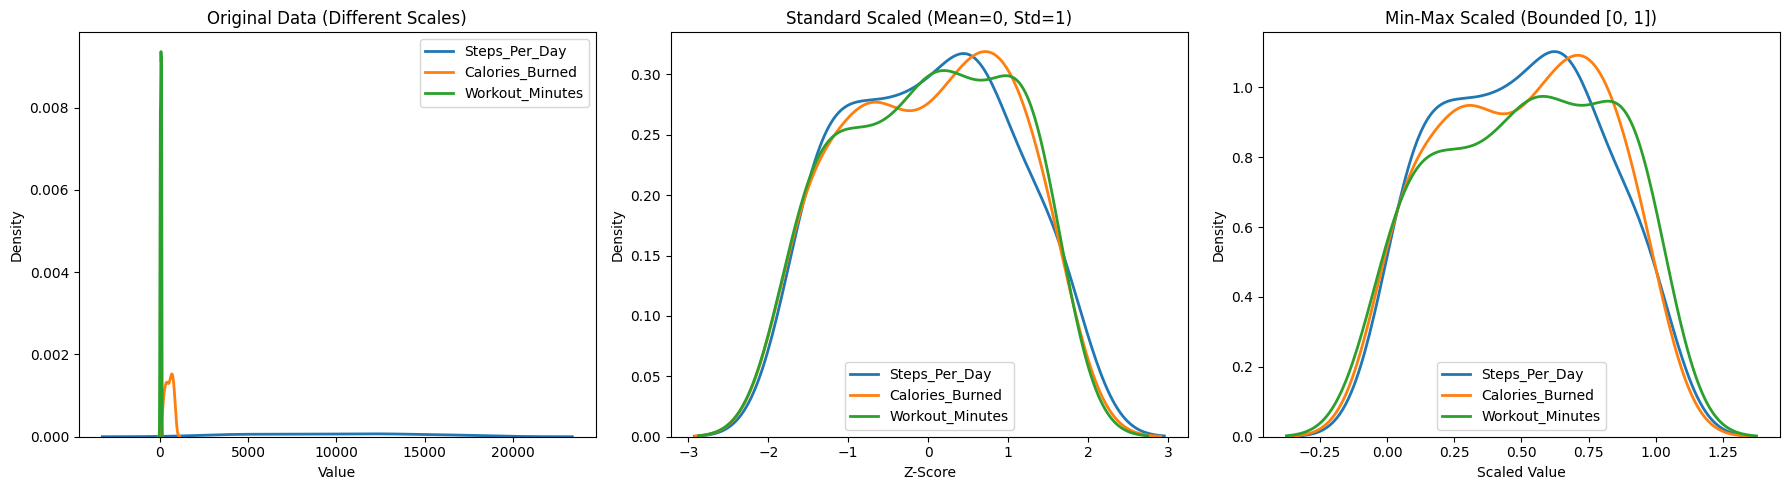

In [ ]:
# 3. Statistical Comparison
print("--- STATISTICAL ANALYSIS ---")
# Create DataFrames from the scaled arrays for easier column access
df_standard_scaled = pd.DataFrame(data_standard, columns=data_numerical.columns)
df_minmax_scaled = pd.DataFrame(data_minmax, columns=data_numerical.columns)

for i in data_numerical.columns:
    comparison_df = pd.DataFrame({
        'Original': data_numerical[i],
        'Standard Scaled': df_standard_scaled[i],
        'Min-Max Scaled': df_minmax_scaled[i]
    })
    print( f" Metrics for {i} ")
    print("="*55)
    print(comparison_df.describe().loc[['mean', 'std', 'min', 'max']].round(4))

# 4. Visual Comparison Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Original Data Distribution
for col_name in data_numerical.columns:
    sns.kdeplot(data_numerical[col_name], ax=axes[0], label=col_name, linewidth=2)
axes[0].set_title('Original Data (Different Scales)')
axes[0].set_xlabel('Value')
axes[0].legend()

# Standard Scaled Distribution
for i, col_name in enumerate(data_numerical.columns):
    sns.kdeplot(data_standard[:, i], ax=axes[1], label=col_name, linewidth=2)
axes[1].set_title('Standard Scaled (Mean=0, Std=1)')
axes[1].set_xlabel('Z-Score')
axes[1].legend()


# Min-Max Scaled Distribution
for i, col_name in enumerate(data_numerical.columns):
    sns.kdeplot(data_minmax[:, i], ax=axes[2], label=col_name, linewidth=2)
axes[2].set_title('Min-Max Scaled (Bounded [0, 1])')
axes[2].set_xlabel('Scaled Value')
axes[2].legend()

plt.tight_layout()
plt.show()